In [3]:
import os, sys, pickle, importlib, numpy as np, pandas as pd

REPO = '/grid/wsbs/home_norepl/pmantill/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra'
sys.path.insert(0, os.path.join(REPO, 'eigen-interactions'))
import eigen_steering
importlib.reload(eigen_steering)
eigen_steering.WEIGHTS_PATH = '/grid/wsbs/home_norepl/pmantill/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/pytorch_base_model/model_fold_0.safetensors'
eigen_steering.RESULTS_DIR = os.path.join(REPO, 'models')
from eigen_steering import EigenMap

lib_path = os.path.join(REPO, 'virtual_perturbations', 'libraries', 'hippo_target_library.pkl')
with open(lib_path, 'rb') as f:
    lib = pickle.load(f)

df = lib['df']
focus_tfs = lib['focus_tfs']

# Build EigenMap — HepG2 first so it plots on top
CT = {'HepG2': 'HepG2_v6_do03', 'K562': 'K562_v6_do075'}
em = EigenMap(model_names=CT, device='cuda')

em.load_from_dataframe(df, seq_col='sequence')
em.set_actual({ct: df[f'{ct}_log2FC'].values for ct in CT})

# Build seq_idx -> raw npz index mapping (npz has all seq_valid rows,
# df used the additional keep filter dropping 3 rows)
raw = np.load(lib['attr_npz_path'])
df_full = pd.read_csv(os.path.join(REPO, 'data', 'joint_library_combined.csv'))
seq_valid = df_full['sequence'].notna()
n = seq_valid.sum()
keep = df_full.loc[seq_valid, ['sequence'] + [f'{ct}_log2FC' for ct in CT]].notna().all(axis=1).values
raw_indices = np.arange(n)[keep]  # filtered_idx -> raw npz idx
del df_full

ohe = em.X.numpy()
idxs = df.seq_idx.values
npz_idxs = raw_indices[idxs]  # correct mapping
for ct in CT:
    hyp = raw[f'attr_{ct}'][npz_idxs]
    em.attr_hyp[ct] = hyp
    em.attr[ct] = hyp * ohe
    em.importance[ct] = em.attr[ct].sum(axis=1)
    em.predictions[ct] = raw[f'predictions_{ct}'][npz_idxs]

em.motif_hits = lib['motif_hits']
em.eigen_results = lib['eigen_results']

print(f'Loaded {len(df)} sequences')
print(f'  Conditions: {df["condition"].value_counts().to_dict()}')
print(f'  Focus TFs: {len(focus_tfs)}')
print(f'  Cell type order: {em.cell_types} (top row first)')

EigenMap: ['HepG2', 'K562'], models={'HepG2': 'HepG2_v6_do03', 'K562': 'K562_v6_do075'}
Loaded 1059 sequences, X shape: torch.Size([1059, 4, 281])
Loaded 1059 sequences
  Conditions: {'same-diff': 353, 'diff-diff': 353, 'same-same': 353}
  Focus TFs: 151
  Cell type order: ['HepG2', 'K562'] (top row first)


## Necessity and sufficiency tests across library (local and global effects)

In [6]:
# run necessity and sufficiency tests on all sequences
n_rep = 60
seed = 42
nec_order = 1
suf_order = 1

all_nec = em.necessity_test(seq_idx=None, n_rep=n_rep,
                            nec_order=nec_order, batch_size=256, random_state=seed)
all_suf = em.sufficiency_test(seq_idx=None, n_rep=n_rep,
                              suf_order=suf_order, suff_pos=None,
                              batch_size=256, random_state=seed)

  Loading HepG2: /grid/wsbs/home_norepl/pmantill/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/models/HepG2_v6_do03/checkpoints/best_stage2.pt
  Loading K562: /grid/wsbs/home_norepl/pmantill/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/models/K562_v6_do075/checkpoints/best_stage2.pt
  necessity: 1059/1059 sequences
  Loading HepG2: /grid/wsbs/home_norepl/pmantill/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/models/HepG2_v6_do03/checkpoints/best_stage2.pt
  Loading K562: /grid/wsbs/home_norepl/pmantill/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/models/K562_v6_do075/checkpoints/best_stage2.pt
  sufficiency: 1059/1059 sequences


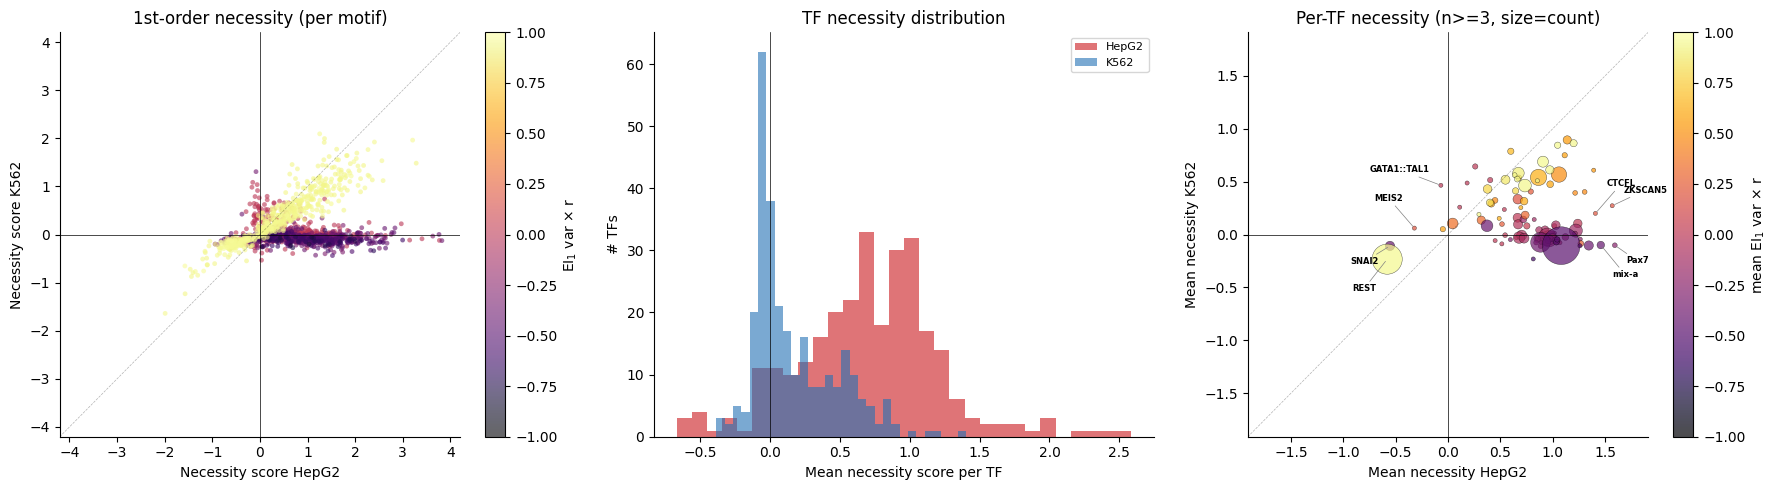

1647 motif tests, 100 TFs with n>=3


In [7]:
import matplotlib.pyplot as plt

# collect 1st-order necessity scores (flip sign: positive = more necessary)
nec_rows = []
for si, tests in enumerate(all_nec):
    for t in tests:
        if t['order'] == 1:
            nec_rows.append({
                'seq_idx': si,
                'tf': t['motifs'][0]['tf'],
                'nec_HepG2': -t['scores']['HepG2'],
                'nec_K562': -t['scores']['K562'],
                'EI_1_vxr': df.iloc[si]['EI_1 var x r'],
            })
nec_df = pd.DataFrame(nec_rows)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) per-motif HepG2 vs K562 necessity
order = np.argsort(np.abs(nec_df['EI_1_vxr'].values))
sc = axes[0].scatter(nec_df.nec_HepG2.values[order], nec_df.nec_K562.values[order],
                     s=12, alpha=0.6, c=nec_df['EI_1_vxr'].values[order],
                     cmap='inferno', vmin=-1, vmax=1, edgecolors='none')
lim = np.abs(nec_df[['nec_HepG2','nec_K562']].values).max() * 1.1
axes[0].set_xlim(-lim, lim); axes[0].set_ylim(-lim, lim)
axes[0].axhline(0, c='k', lw=0.5); axes[0].axvline(0, c='k', lw=0.5)
axes[0].plot([-lim, lim], [-lim, lim], 'k--', lw=0.5, alpha=0.3)
axes[0].set_xlabel('Necessity score HepG2'); axes[0].set_ylabel('Necessity score K562')
plt.colorbar(sc, ax=axes[0], label='EI$_1$ var $\\times$ r')
axes[0].set_title('1st-order necessity (per motif)')

# 2) per-TF mean score distribution
tf_h = nec_df.groupby('tf')['nec_HepG2'].mean()
tf_k = nec_df.groupby('tf')['nec_K562'].mean()
axes[1].hist(tf_h, bins=30, alpha=0.6, color='#cb181d', label='HepG2')
axes[1].hist(tf_k, bins=30, alpha=0.6, color='#2171b5', label='K562')
axes[1].axvline(0, c='k', lw=0.5)
axes[1].set_xlabel('Mean necessity score per TF'); axes[1].set_ylabel('# TFs')
axes[1].legend(fontsize=8)
axes[1].set_title('TF necessity distribution')

# 3) per-TF scatter, colored by mean EI
tf_agg = nec_df.groupby('tf').agg(
    h=('nec_HepG2', 'mean'), k=('nec_K562', 'mean'),
    ei=('EI_1_vxr', 'mean'), n=('seq_idx', 'count')).reset_index()
tf_agg = tf_agg[tf_agg.n >= 3]
tf_agg['off_diag'] = np.abs(tf_agg.h - tf_agg.k)

order_tf = np.argsort(np.abs(tf_agg['ei'].values))
sc2 = axes[2].scatter(tf_agg.h.values[order_tf], tf_agg.k.values[order_tf],
                      s=tf_agg.n.values[order_tf] * 3, alpha=0.7,
                      c=tf_agg.ei.values[order_tf],
                      cmap='inferno', vmin=-1, vmax=1, edgecolors='k', linewidths=0.3)
tlim = np.abs(tf_agg[['h','k']].values).max() * 1.2
axes[2].set_xlim(-tlim, tlim); axes[2].set_ylim(-tlim, tlim)
axes[2].axhline(0, c='k', lw=0.5); axes[2].axvline(0, c='k', lw=0.5)
axes[2].plot([-tlim, tlim], [-tlim, tlim], 'k--', lw=0.5, alpha=0.3)

# top 2 most deviated from y=x per quadrant
quads = [
    (tf_agg[(tf_agg.h > 0) & (tf_agg.k > 0)], 'left', 'bottom', (8, 8), (8, 18)),
    (tf_agg[(tf_agg.h < 0) & (tf_agg.k > 0)], 'right', 'bottom', (-8, 8), (-8, 18)),
    (tf_agg[(tf_agg.h > 0) & (tf_agg.k < 0)], 'left', 'top', (8, -8), (8, -18)),
    (tf_agg[(tf_agg.h < 0) & (tf_agg.k < 0)], 'right', 'top', (-8, -8), (-8, -18)),
]
for q, ha, va, off1, off2 in quads:
    if len(q) == 0:
        continue
    tops = q.nlargest(min(2, len(q)), 'off_diag')
    for j, (_, row) in enumerate(tops.iterrows()):
        off = off1 if j == 0 else off2
        axes[2].annotate(row.tf, (row.h, row.k), fontsize=6, fontweight='bold',
                         ha=ha, va=va, xytext=off, textcoords='offset points',
                         arrowprops=dict(arrowstyle='-', color='grey', lw=0.5, shrinkA=0, shrinkB=2))

axes[2].set_xlabel('Mean necessity HepG2'); axes[2].set_ylabel('Mean necessity K562')
plt.colorbar(sc2, ax=axes[2], label='mean EI$_1$ var $\\times$ r')
axes[2].set_title(f'Per-TF necessity (n>={3}, size=count)')

for ax in axes:
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print(f'{len(nec_df)} motif tests, {len(tf_agg)} TFs with n>=3')

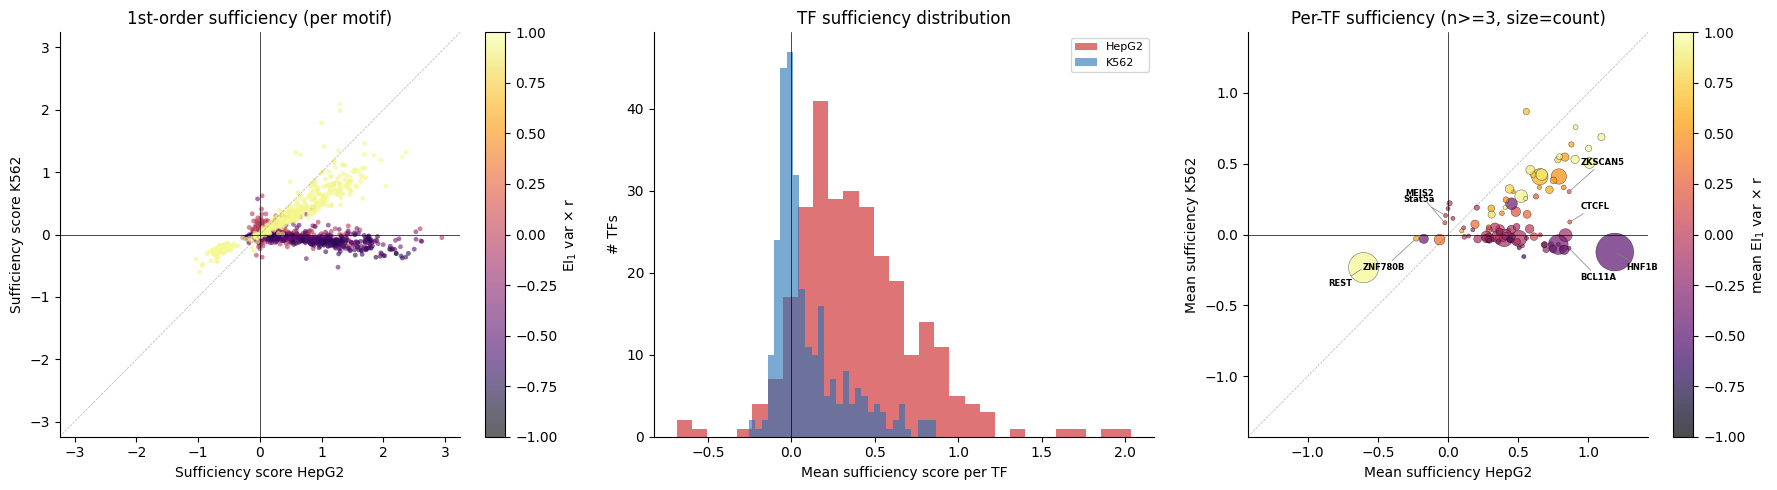

1647 motif tests, 100 TFs with n>=3


In [8]:
# collect 1st-order sufficiency scores
suf_rows = []
for si, tests in enumerate(all_suf):
    for t in tests:
        if t['order'] == 1:
            suf_rows.append({
                'seq_idx': si,
                'tf': t['motifs'][0]['tf'],
                'suf_HepG2': t['scores']['HepG2'],
                'suf_K562': t['scores']['K562'],
                'EI_1_vxr': df.iloc[si]['EI_1 var x r'],
            })
suf_df = pd.DataFrame(suf_rows)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) per-motif HepG2 vs K562 sufficiency
order = np.argsort(np.abs(suf_df['EI_1_vxr'].values))
sc = axes[0].scatter(suf_df.suf_HepG2.values[order], suf_df.suf_K562.values[order],
                     s=12, alpha=0.6, c=suf_df['EI_1_vxr'].values[order],
                     cmap='inferno', vmin=-1, vmax=1, edgecolors='none')
lim = np.abs(suf_df[['suf_HepG2','suf_K562']].values).max() * 1.1
axes[0].set_xlim(-lim, lim); axes[0].set_ylim(-lim, lim)
axes[0].axhline(0, c='k', lw=0.5); axes[0].axvline(0, c='k', lw=0.5)
axes[0].plot([-lim, lim], [-lim, lim], 'k--', lw=0.5, alpha=0.3)
axes[0].set_xlabel('Sufficiency score HepG2'); axes[0].set_ylabel('Sufficiency score K562')
plt.colorbar(sc, ax=axes[0], label='EI$_1$ var $\\times$ r')
axes[0].set_title('1st-order sufficiency (per motif)')

# 2) per-TF mean score distribution
tf_h = suf_df.groupby('tf')['suf_HepG2'].mean()
tf_k = suf_df.groupby('tf')['suf_K562'].mean()
axes[1].hist(tf_h, bins=30, alpha=0.6, color='#cb181d', label='HepG2')
axes[1].hist(tf_k, bins=30, alpha=0.6, color='#2171b5', label='K562')
axes[1].axvline(0, c='k', lw=0.5)
axes[1].set_xlabel('Mean sufficiency score per TF'); axes[1].set_ylabel('# TFs')
axes[1].legend(fontsize=8)
axes[1].set_title('TF sufficiency distribution')

# 3) per-TF scatter, colored by mean EI
tf_agg = suf_df.groupby('tf').agg(
    h=('suf_HepG2', 'mean'), k=('suf_K562', 'mean'),
    ei=('EI_1_vxr', 'mean'), n=('seq_idx', 'count')).reset_index()
tf_agg = tf_agg[tf_agg.n >= 3]
tf_agg['off_diag'] = np.abs(tf_agg.h - tf_agg.k)

order_tf = np.argsort(np.abs(tf_agg['ei'].values))
sc2 = axes[2].scatter(tf_agg.h.values[order_tf], tf_agg.k.values[order_tf],
                      s=tf_agg.n.values[order_tf] * 3, alpha=0.7,
                      c=tf_agg.ei.values[order_tf],
                      cmap='inferno', vmin=-1, vmax=1, edgecolors='k', linewidths=0.3)
tlim = np.abs(tf_agg[['h','k']].values).max() * 1.2
axes[2].set_xlim(-tlim, tlim); axes[2].set_ylim(-tlim, tlim)
axes[2].axhline(0, c='k', lw=0.5); axes[2].axvline(0, c='k', lw=0.5)
axes[2].plot([-tlim, tlim], [-tlim, tlim], 'k--', lw=0.5, alpha=0.3)

quads = [
    (tf_agg[(tf_agg.h > 0) & (tf_agg.k > 0)], 'left', 'bottom', (8, 8), (8, 18)),
    (tf_agg[(tf_agg.h < 0) & (tf_agg.k > 0)], 'right', 'bottom', (-8, 8), (-8, 18)),
    (tf_agg[(tf_agg.h > 0) & (tf_agg.k < 0)], 'left', 'top', (8, -8), (8, -18)),
    (tf_agg[(tf_agg.h < 0) & (tf_agg.k < 0)], 'right', 'top', (-8, -8), (-8, -18)),
]
for q, ha, va, off1, off2 in quads:
    if len(q) == 0:
        continue
    tops = q.nlargest(min(2, len(q)), 'off_diag')
    for j, (_, row) in enumerate(tops.iterrows()):
        off = off1 if j == 0 else off2
        axes[2].annotate(row.tf, (row.h, row.k), fontsize=6, fontweight='bold',
                         ha=ha, va=va, xytext=off, textcoords='offset points',
                         arrowprops=dict(arrowstyle='-', color='grey', lw=0.5, shrinkA=0, shrinkB=2))

axes[2].set_xlabel('Mean sufficiency HepG2'); axes[2].set_ylabel('Mean sufficiency K562')
plt.colorbar(sc2, ax=axes[2], label='mean EI$_1$ var $\\times$ r')
axes[2].set_title(f'Per-TF sufficiency (n>={3}, size=count)')

for ax in axes:
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print(f'{len(suf_df)} motif tests, {len(tf_agg)} TFs with n>=3')

In [9]:
# save results
save_dir = os.path.join(REPO, 'virtual_perturbations', 'results')
os.makedirs(save_dir, exist_ok=True)

fname = f'virtual_perturbation_results_{n_rep}_seed{seed}.pkl'
with open(os.path.join(save_dir, fname), 'wb') as f:
    pickle.dump({
        'necessity': all_nec,
        'sufficiency': all_suf,
        'n_rep': n_rep,
        'nec_order': nec_order,
        'suf_order': suf_order,
        'seed': seed,
    }, f)

print(f'Saved to {save_dir}/{fname}')

Saved to /grid/wsbs/home_norepl/pmantill/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/virtual_perturbations/results/virtual_perturbation_results_60_seed42.pkl
